# Phase 2: Model Training
## Healthcare High-Cost Utilizer Prediction
### Arid Agriculture University Rawalpindi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported")

✅ All libraries imported


## Step 1: Data Loading & Train/Test Split

In [2]:
df = pd.read_csv('../data/processed.csv')

feature_cols = ['Gender', 'Visit_Count', 'Test_Freq', 
                'Test_Diversity', 'Repeat_Test_Count', 
                'num_BLOOD_tests', 'num_RADIOLOGY_tests',
                'num_URINE_tests', 'num_STOOL_tests', 
                'num_SPUTUM_tests', 'Monthly_Test_Trend', 
                'Moral_Hazard_Index']

X = df[feature_cols]
y = df['High_Cost_Utilizer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

Train: (1666, 12) | Test: (714, 12)
Class distribution: {0: 1903, 1: 477}


## Step 2: SMOTE — Class Imbalance Handle

In [3]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 1332, 1: 334}
After  SMOTE: {1: 1332, 0: 1332}


## Step 3: Logistic Regression

In [4]:
lr = LogisticRegression(
    penalty='elasticnet', solver='saga',
    class_weight='balanced', max_iter=1000, random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, 
                       scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_sm, y_train_sm)
best_lr = grid_lr.best_estimator_

print(f"Best params: {grid_lr.best_params_}")
print(f"CV ROC-AUC: {grid_lr.best_score_:.4f}")

Best params: {'C': 0.1, 'l1_ratio': 0.1}
CV ROC-AUC: 0.9737


In [5]:
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

Accuracy : 0.9496
Precision: 0.8323
Recall   : 0.9371
F1 Score : 0.8816
ROC-AUC  : 0.9826


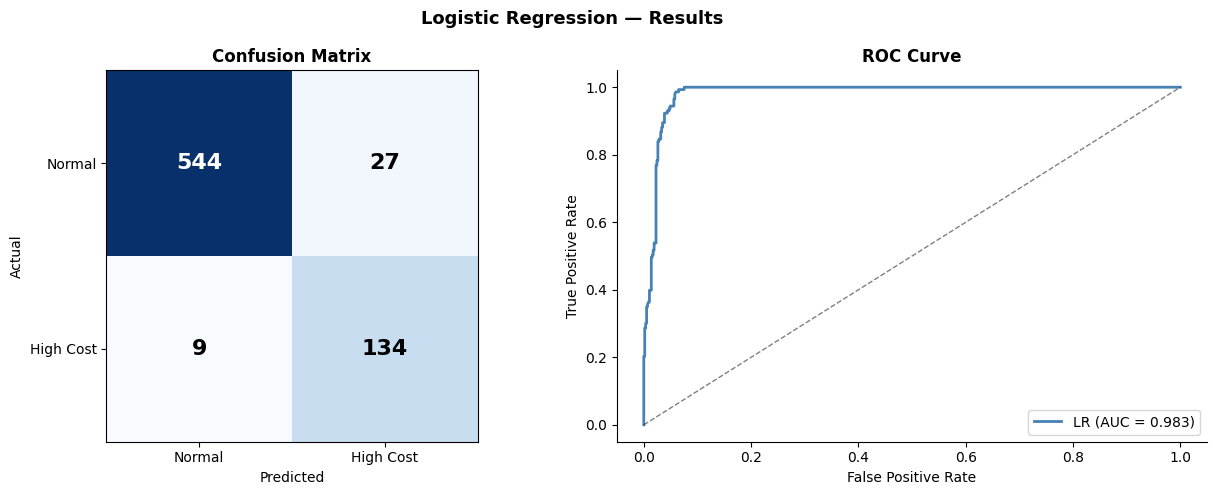

✅ Saved: results/lr_results.png


In [6]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression — Results', 
             fontsize=13, fontweight='bold')

# Confusion Matrix
axes[0].imshow(cm_lr, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal', 'High Cost'])
axes[0].set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_lr[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_lr[i,j] > cm_lr.max()/2 
                     else 'black')

# ROC Curve
axes[1].plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
             label=f'LR (AUC = {auc_lr:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/lr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/lr_results.png")

## Step 4: Random Forest

In [7]:
rf = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5,
                       scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_sm, y_train_sm)
best_rf = grid_rf.best_estimator_

print(f"Best params: {grid_rf.best_params_}")
print(f"CV ROC-AUC: {grid_rf.best_score_:.4f}")

Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
CV ROC-AUC: 0.9950


Accuracy : 0.9482
ROC-AUC  : 0.9901


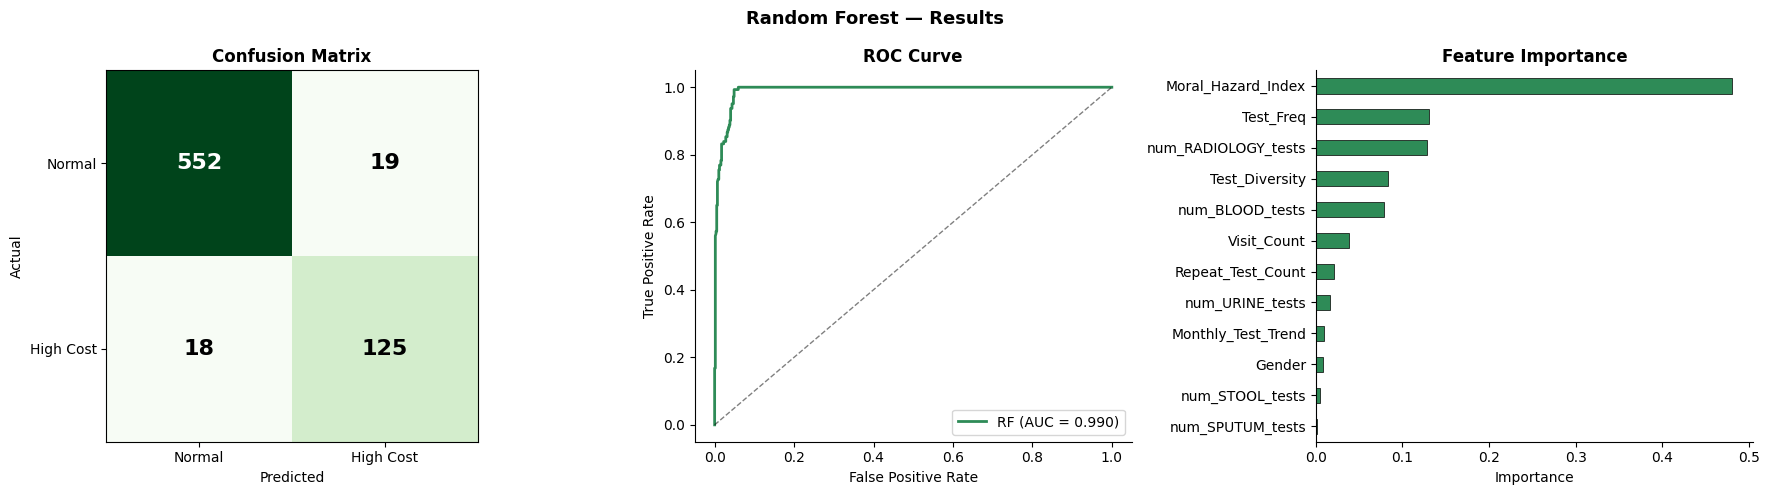

✅ Saved: rf_results.png + rf_model.pkl
{'Model': 'Random Forest', 'Accuracy': 0.9482, 'Precision': 0.8681, 'Recall': 0.8741, 'F1': 0.8711, 'ROC_AUC': 0.9901}


In [8]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {auc_rf:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Results', 
             fontsize=13, fontweight='bold')

# Confusion Matrix
axes[0].imshow(cm_rf, cmap='Greens')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal', 'High Cost'])
axes[0].set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_rf[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_rf[i,j] > cm_rf.max()/2 
                     else 'black')

# ROC Curve
axes[1].plot(fpr_rf, tpr_rf, color='seagreen', lw=2,
             label=f'RF (AUC = {auc_rf:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

# Feature Importance
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='seagreen',
              edgecolor='black', linewidth=0.5)
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(best_rf, '../models/rf_model.pkl')
print("✅ Saved: rf_results.png + rf_model.pkl")

rf_metrics = {
    'Model'    : 'Random Forest',
    'Accuracy' : round(accuracy_score(y_test, y_pred_rf), 4),
    'Precision': round(precision_score(y_test, y_pred_rf), 4),
    'Recall'   : round(recall_score(y_test, y_pred_rf), 4),
    'F1'       : round(f1_score(y_test, y_pred_rf), 4),
    'ROC_AUC'  : round(auc_rf, 4)}
print(rf_metrics)

## Step 5: SVM

Best params: {'C': 100, 'gamma': 0.1}
Accuracy : 0.9398
ROC-AUC  : 0.9669


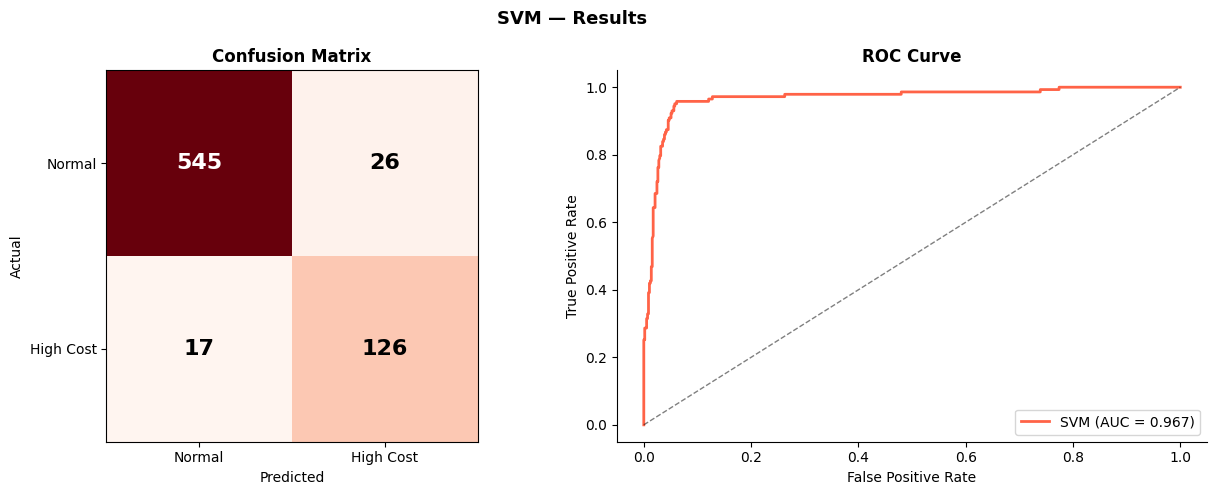

✅ Saved: svm_results.png + svm_model.pkl
{'Model': 'SVM', 'Accuracy': 0.9398, 'Precision': 0.8289, 'Recall': 0.8811, 'F1': 0.8542, 'ROC_AUC': 0.9669}


In [16]:
svm = SVC(kernel='rbf', class_weight='balanced',
          probability=True, random_state=42)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]}

grid_svm = GridSearchCV(svm, param_grid_svm, cv=5,
                        scoring='roc_auc', n_jobs=-1)
grid_svm.fit(X_train_sm, y_train_sm)
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]
cm_svm = confusion_matrix(y_test, y_pred_svm)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f"Best params: {grid_svm.best_params_}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC  : {auc_svm:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SVM — Results', fontsize=13, fontweight='bold')

axes[0].imshow(cm_svm, cmap='Reds')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Normal', 'High Cost'])
axes[0].set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_svm[i,j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_svm[i,j] > cm_svm.max()/2 
                     else 'black')

axes[1].plot(fpr_svm, tpr_svm, color='tomato', lw=2,
             label=f'SVM (AUC = {auc_svm:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/svm_results.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(best_svm, '../models/svm_model.pkl')
print("✅ Saved: svm_results.png + svm_model.pkl")

svm_metrics = {
    'Model'    : 'SVM',
    'Accuracy' : round(accuracy_score(y_test, y_pred_svm), 4),
    'Precision': round(precision_score(y_test, y_pred_svm), 4),
    'Recall'   : round(recall_score(y_test, y_pred_svm), 4),
    'F1'       : round(f1_score(y_test, y_pred_svm), 4),
    'ROC_AUC'  : round(auc_svm, 4)}
print(svm_metrics)

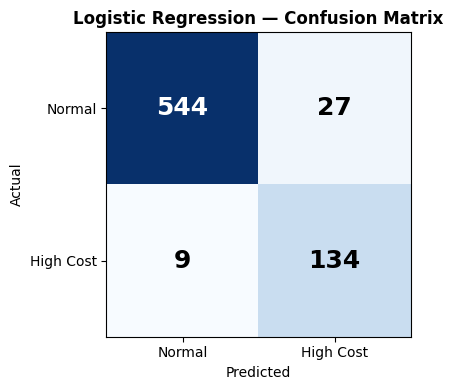

In [9]:
# === LR — Confusion Matrix ===
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_lr, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', 
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_lr[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_lr[i,j] > cm_lr.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/lr_cm.png', dpi=150, bbox_inches='tight')
plt.show()

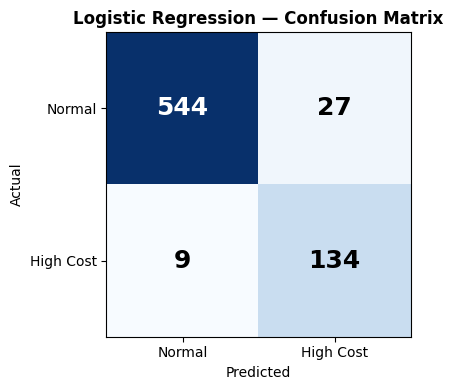

In [10]:
# === LR — Confusion Matrix ===
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_lr, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', 
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_lr[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_lr[i,j] > cm_lr.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/lr_cm.png', dpi=150, bbox_inches='tight')
plt.show()

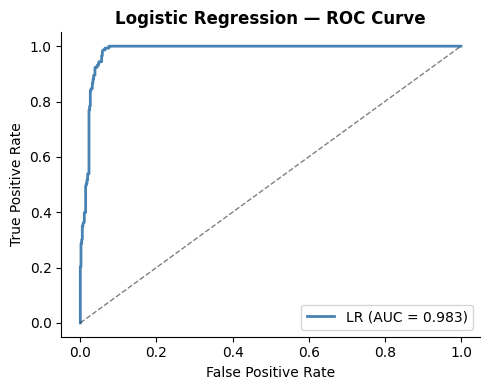

In [11]:
# === LR — ROC Curve ===
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
        label=f'LR (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('Logistic Regression — ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/lr_roc.png', dpi=150, bbox_inches='tight')
plt.show()

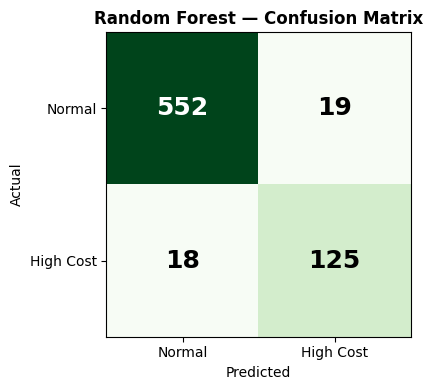

In [12]:
# === RF — Confusion Matrix ===
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_rf, cmap='Greens')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_rf[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_rf[i,j] > cm_rf.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/rf_cm.png', dpi=150, bbox_inches='tight')
plt.show()

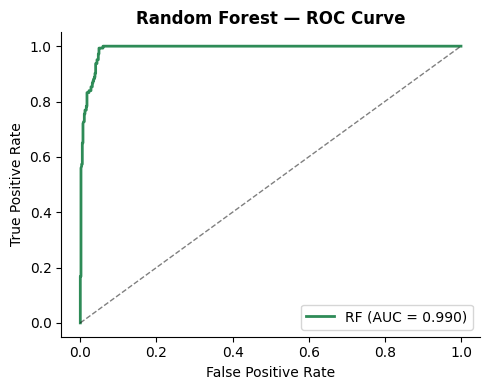

In [13]:
# === RF — ROC Curve ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_rf, tpr_rf, color='seagreen', lw=2,
        label=f'RF (AUC = {auc_rf:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('Random Forest — ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/rf_roc.png', dpi=150, bbox_inches='tight')
plt.show()

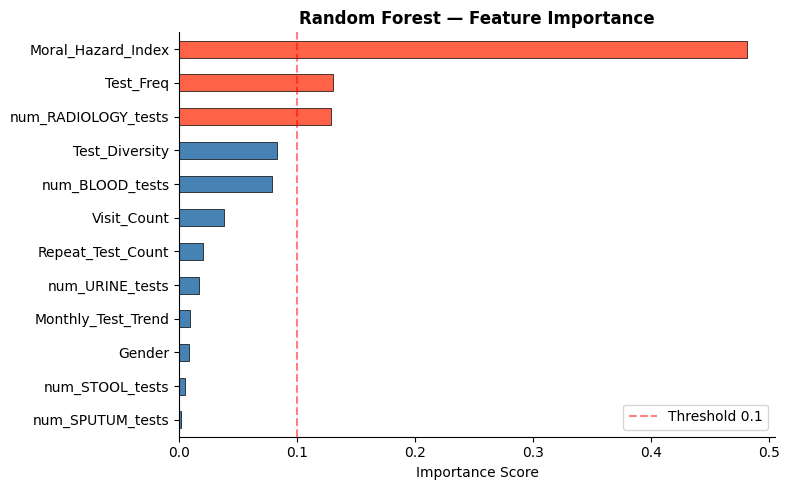

In [14]:
# === RF — Feature Importance ===
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = ['tomato' if v > 0.1 else 'steelblue' 
             for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi,
              edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Feature Importance', 
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=0.1, color='red', linestyle='--', 
           alpha=0.5, label='Threshold 0.1')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

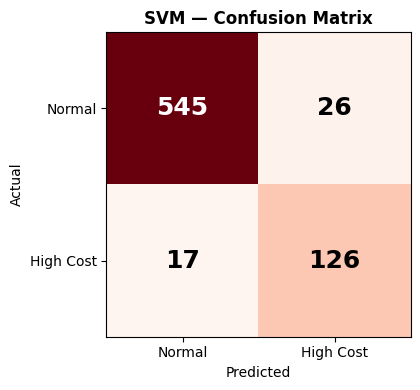

In [17]:
# === SVM — Confusion Matrix ===
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_svm, cmap='Reds')
ax.set_title('SVM — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_svm[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_svm[i,j] > cm_svm.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/svm_cm.png', dpi=150, bbox_inches='tight')
plt.show()

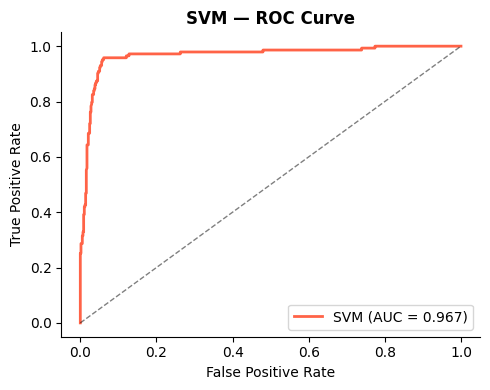

In [18]:
# === SVM — ROC Curve ===
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_svm, tpr_svm, color='tomato', lw=2,
        label=f'SVM (AUC = {auc_svm:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('SVM — ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/svm_roc.png', dpi=150, bbox_inches='tight')
plt.show()